In [1]:
! python seq_saliency_full_chromosome_HOCOMOCO.py \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/hESC_universal_5kb_8_tracks_KO_fix_mask.ckpt \
    --chr chr20 \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --resolution 4096 \
    --matrix-size 512 \
    --meme-file tmp/H13CORE_meme_format.meme \
    --out-file outputs/chr20_attribution.bw

Using device: cuda
Processing chr20 with length 63025520...
Processing chromosome windows: 100%|██████████| 117/117 [02:59<00:00,  1.53s/it]
Averaging scores from overlapping windows...
Saving chromosome-wide attribution scores...
Successfully saved attribution scores to outputs/chr20_attribution.bw
Scanning for motifs across the entire chromosome...
Successfully parsed 1611 motifs from tmp/H13CORE_meme_format.meme
Moving gradients to GPU for motif scanning...
Scanning motifs on GPU: 100%|███████████████| 1611/1611 [11:07<00:00,  2.41it/s]
Found 9064253 motif occurrences above the score threshold.
Saved motif scanning results to outputs/chr20_attribution_motifs.tsv

Top 40 motifs correlated with saliency scores:
                           motif       pos  score_max
3609750      KMT2B.H13CORE.0.P.B  48041397  48.327404
3640371      KMT2B.H13CORE.0.P.B  56337692  48.076168
3640443      KMT2B.H13CORE.0.P.B  56337766  46.736732
3530758      KMT2B.H13CORE.0.P.B   5731080  46.462105
3570953 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('outputs/chr20_attribution_motifs.tsv', sep='\t')
df

,motif,pos,score_fw,score_rc,score_max,pos_100bp
0,AHCTF1.H13CORE.0.B.B,327717,4.548167,5.032453,5.032453,327700
1,AHCTF1.H13CORE.0.B.B,327843,5.978563,5.719033,5.978563,327800
2,AHCTF1.H13CORE.0.B.B,372038,4.029919,6.615910,6.615910,372000
3,AHCTF1.H13CORE.0.B.B,388128,5.877393,2.080493,5.877393,388100
4,AHCTF1.H13CORE.0.B.B,388485,9.115216,7.578565,9.115216,388400
...,...,...,...,...,...,...
1384273,ZXDC.H13CORE.0.PI.A,61460351,5.122258,-0.347480,5.122258,61460300
1384274,ZXDC.H13CORE.0.PI.A,61703628,-5.712800,0.034967,5.712800,61703600
1384275,ZXDC.H13CORE.0.PI.A,61703778,-5.933580,-0.236888,5.933580,61703700
1384276,ZXDC.H13CORE.0.PI.A,62808048,0.691707,5.582713,5.582713,62808000


In [4]:
# score is whichever has greatest absolute value
df['score'] = df[['score_fw', 'score_rc']].apply(lambda x: x['score_fw'] if abs(x['score_fw']) >= abs(x['score_rc']) else x['score_rc'], axis=1)

In [5]:
df

,motif,pos,score_fw,score_rc,score_max,pos_100bp,score
0,AHCTF1.H13CORE.0.B.B,327717,4.548167,5.032453,5.032453,327700,5.032453
1,AHCTF1.H13CORE.0.B.B,327843,5.978563,5.719033,5.978563,327800,5.978563
2,AHCTF1.H13CORE.0.B.B,372038,4.029919,6.615910,6.615910,372000,6.615910
3,AHCTF1.H13CORE.0.B.B,388128,5.877393,2.080493,5.877393,388100,5.877393
4,AHCTF1.H13CORE.0.B.B,388485,9.115216,7.578565,9.115216,388400,9.115216
...,...,...,...,...,...,...,...
1384273,ZXDC.H13CORE.0.PI.A,61460351,5.122258,-0.347480,5.122258,61460300,5.122258
1384274,ZXDC.H13CORE.0.PI.A,61703628,-5.712800,0.034967,5.712800,61703600,-5.712800
1384275,ZXDC.H13CORE.0.PI.A,61703778,-5.933580,-0.236888,5.933580,61703700,-5.933580
1384276,ZXDC.H13CORE.0.PI.A,62808048,0.691707,5.582713,5.582713,62808000,5.582713


In [6]:
# keep only most positive and most negative attributions per position (pos_100bp)
df_top_pos = df.groupby('pos_100bp').apply(lambda x: x.loc[x['score'].abs().idxmax()]).reset_index(drop=True)
df_top_neg = df.groupby('pos_100bp').apply(lambda x: x.loc[x['score'].abs().idxmin()]).reset_index(drop=True)
df_top = pd.concat([df_top_pos, df_top_neg])
df_top.sort_values('pos_100bp', inplace=True)
df_top

/tmp/ipykernel_3914127/3803176119.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top_pos = df.groupby('pos_100bp').apply(lambda x: x.loc[x['score'].abs().idxmax()]).reset_index(drop=True)
/tmp/ipykernel_3914127/3803176119.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top_neg = df.groupby('pos_100bp').apply(lambda x: x.loc[x['score'].abs().idxmin()]).reset_index(drop=True)


,motif,pos,score_fw,score_rc,score_max,pos_100bp,score
0,KMT2B.H13CORE.0.P.B,86524,6.038351,4.245823,6.038351,86500,6.038351
0,KMT2B.H13CORE.0.P.B,86524,6.038351,4.245823,6.038351,86500,6.038351
1,ZBT14.H13CORE.0.P.C,174557,-0.564763,5.433530,5.433530,174500,5.433530
1,KMT2B.H13CORE.0.P.B,174560,5.119680,6.238545,6.238545,174500,6.238545
2,KMT2B.H13CORE.0.P.B,260070,-5.143395,-3.909143,5.143395,260000,-5.143395
...,...,...,...,...,...,...,...
16272,ZBT14.H13CORE.0.P.C,62809819,1.111414,5.054306,5.054306,62809800,5.054306
16273,KMT2B.H13CORE.0.P.B,62814084,-4.730411,-6.113152,6.113152,62814000,-6.113152
16273,KMT2B.H13CORE.0.P.B,62814084,-4.730411,-6.113152,6.113152,62814000,-6.113152
16274,KMT2B.H13CORE.0.P.B,62900619,2.092447,5.197704,5.197704,62900600,5.197704


In [7]:
df_top['motif'].value_counts().head(25)

motif
KMT2B.H13CORE.0.P.B         21046
ZFP57.H13CORE.0.P.B           814
ZN740.H13CORE.0.P.C           736
ZBT14.H13CORE.0.P.C           634
VEZF1.H13CORE.0.P.C           416
KLF7.H13CORE.0.P.B            361
GTF2IRD2.H13CORE.0.PS.A       344
AHCTF1.H13CORE.0.B.B          274
MYPOP.H13CORE.0.PSGB.A        194
ZNF215.H13CORE.0.PSG.A        137
KAISO.H13CORE.0.P.B           137
PATZ1.H13CORE.1.P.C           133
ZIC1.H13CORE.0.P.B            119
CPEB1.H13CORE.0.S.B           119
SP2.H13CORE.0.P.D             117
GLYR1.H13CORE.0.B.B           110
SLC2A4RG.H13CORE.0.PSG.A      109
LMX1B.H13CORE.0.P.C           103
ZBT7A.H13CORE.0.P.B           102
BMAL1.H13CORE.0.PSM.A          96
ZNF703.H13CORE.0.P.C           94
ZNF888.H13CORE.0.P.B           91
GCM2.H13CORE.0.SM.B            88
ZNF131.H13CORE.0.PSGI.A        87
ZNF362.H13CORE.0.PSGI.A        86
Name: count, dtype: int64

In [8]:
df.sort_values('pos').head(20)

,motif,pos,score_fw,score_rc,score_max,pos_100bp,score
540137,KMT2B.H13CORE.0.P.B,86524,6.038351,4.245823,6.038351,86500,6.038351
1033936,ZBT14.H13CORE.0.P.C,174557,-0.564763,5.433530,5.433530,174500,5.433530
540138,KMT2B.H13CORE.0.P.B,174560,5.119680,6.238545,6.238545,174500,6.238545
540139,KMT2B.H13CORE.0.P.B,260070,-5.143395,-3.909143,5.143395,260000,-5.143395
540140,KMT2B.H13CORE.0.P.B,327697,-3.773222,-5.363954,5.363954,327600,-5.363954
1033937,ZBT14.H13CORE.0.P.C,327697,0.525293,-6.079561,6.079561,327600,-6.079561
1343646,ZNF705EP.H13CORE.0.P.B,327704,-5.135971,1.920942,5.135971,327700,-5.135971
1207122,ZN519.H13CORE.0.P.C,327705,-4.229633,-5.073693,5.073693,327700,-5.073693
1259067,ZN740.H13CORE.0.P.C,327706,-5.775381,0.117464,5.775381,327700,-5.775381
1198601,ZN468.H13CORE.0.P.C,327710,-5.569290,0.076623,5.569290,327700,-5.569290


In [9]:
# find mean effect of each motif
motif_means = df.groupby('motif')[['score_fw', 'score_rc']].mean().reset_index()
motif_means[motif_means['motif'] == 'PATZ1.H13CORE.1.P.C']

,motif,score_fw,score_rc
753,PATZ1.H13CORE.1.P.C,-0.4419,-0.383182


<Axes: xlabel='score', ylabel='Count'>

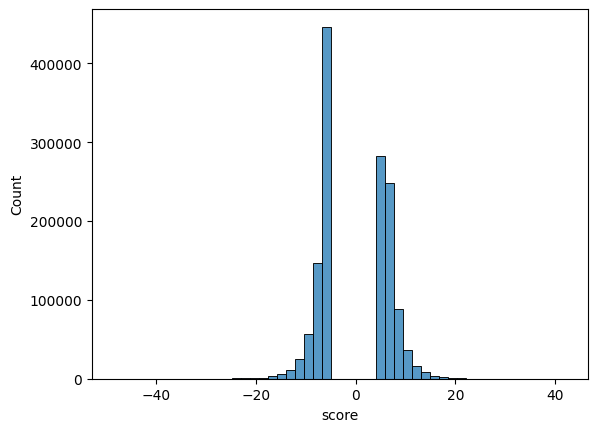

In [10]:
sns.histplot(df['score'], bins=50)

    motif  score_max  score_max_positive  frequency  score_max_negative
0  AHCTF1   7.253661           27.997854       4508          -24.524433
1     AHR   7.278666           23.591356       3644          -30.690210
2    AHRR   7.053035           19.245638       1880          -24.014782
3    ALX1   6.533777           13.678519        318          -10.840743
4    ALX3   6.673602           16.351063       1079          -14.624763


([Text(27.686643495190523, 11066.783005268546, 'SP1'),
  Text(30.815865638671383, 9045.793946740629, 'ZIC1'),
  Text(24.350581394503195, 8827.622029007332, 'ZIC5'),
  Text(26.62748781616456, 5819.634953233411, 'MYCN'),
  Text(31.137203097866433, 7141.590135255293, 'LMX1B'),
  Text(-27.848300712770033, 11066.783005268546, 'SP1'),
  Text(-25.80393374319999, 8890.478772860019, 'ZIC1'),
  Text(-31.739570527722762, 8824.516140919708, 'ZN740'),
  Text(-25.303468350133592, 7006.954656298744, 'ZIC5'),
  Text(-30.297389886240794, 6508.70725305193, 'MYCN'),
  Text(-19.512541623084772, 7564.1269704931365, 'LMX1B'),
  Text(-29.097404950849473, 5045.387240679876, 'VEZF1')],
  <matplotlib.patches.FancyArrowPatch at 0x7f0df2a33950>])

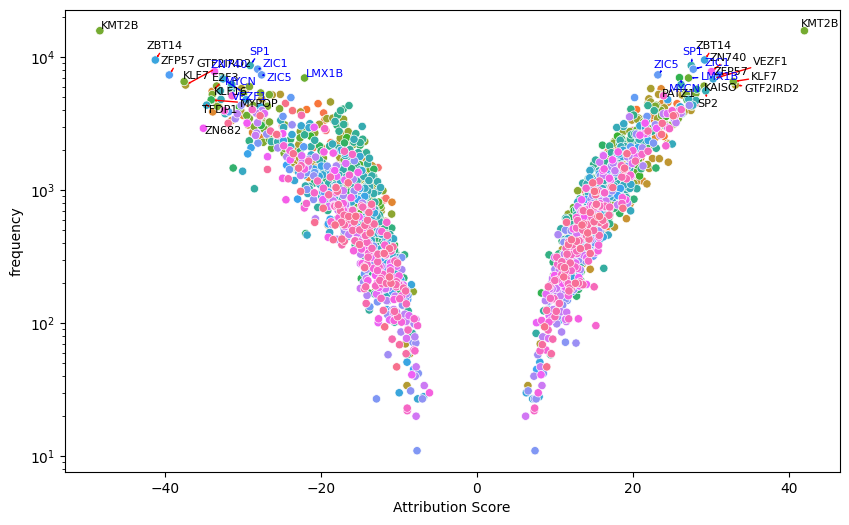

In [11]:
from adjustText import adjust_text

# for each motif plot it's frequency vs average score
# remove suffix from motif name
df['motif'] = df['motif'].apply(lambda x: x.split('.')[0])
motif_groups = df.groupby('motif')
motif_summary = motif_groups.agg({
    'motif': 'first',
    'score_max': 'mean',
    'score': 'max',
    'pos': 'count'
}).rename(columns={'pos': 'frequency'}).reset_index(drop=True)  
motif_summary_min = motif_groups.agg({
    'motif': 'first',
    'score': 'min',
}).reset_index(drop=True).rename(columns={'score': 'score_min'})    
motif_summary = motif_summary.merge(motif_summary_min[['motif', 'score_min']], on='motif')
motif_summary = motif_summary.rename(columns={'score': 'score_max_positive', 'score_min': 'score_max_negative'})
print(motif_summary.head())
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=motif_summary[motif_summary['score_max_positive'] > 0], x='score_max_positive', y='frequency', 
                hue='motif', 
                ax=ax, legend=False)
sns.scatterplot(data=motif_summary[motif_summary['score_max_negative'] < 0], x='score_max_negative', y='frequency', 
                hue='motif', 
                ax=ax, legend=False)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Attribution Score')
# label the top 10 motifs by in each direction
top_pos = motif_summary.nlargest(10, 'score_max_positive')
top_neg = motif_summary.nsmallest(10, 'score_max_negative')
texts = []
for _, row in top_pos.iterrows():
    txt = ax.text(row['score_max_positive'], row['frequency'], row['motif'], fontsize=8)
    texts.append(txt)
for _, row in top_neg.iterrows():
    txt = ax.text(row['score_max_negative'], row['frequency'], row['motif'], fontsize=8)
    texts.append(txt)

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='red'))

# for each side, plot the top 10 by frequency too
top_freq_pos = motif_summary[motif_summary['score_max_positive'] > 0].nlargest(10, 'frequency')
top_freq_neg = motif_summary[motif_summary['score_max_negative'] < 0].nlargest(10, 'frequency')
# remove any already labeled
top_freq_pos = top_freq_pos[~top_freq_pos['motif'].isin(top_pos['motif'])]
top_freq_neg = top_freq_neg[~top_freq_neg['motif'].isin(top_neg['motif'])]
texts = []
for _, row in top_freq_pos.iterrows():
    txt = ax.text(row['score_max_positive'], row['frequency'], row['motif'], fontsize=8, color='blue')
    texts.append(txt)
for _, row in top_freq_neg.iterrows():
    txt = ax.text(row['score_max_negative'], row['frequency'], row['motif'], fontsize=8, color='blue')
    texts.append(txt)
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='blue'))